使用デバイス: cpu
Loads checkpoint by local backend from path: checkpoints/faster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth
model loaded.
inference done.


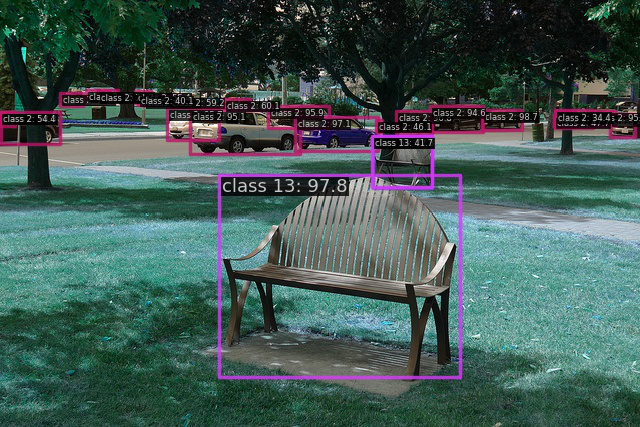

In [1]:
# ======================================
# MMDetection Demo (依存config対応版)
# mmcv==2.1.0 / mmdet==3.3.0 / mmengine==0.10.7
# ======================================

import os, urllib.request, torch, subprocess

# --- 1) mmdetection repo clone ---
if not os.path.exists("mmdetection"):
    subprocess.run(["git", "clone", "-b", "v3.3.0", "https://github.com/open-mmlab/mmdetection.git"])

config_file = "mmdetection/configs/faster_rcnn/faster-rcnn_r50_fpn_1x_coco.py"
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("demo", exist_ok=True)

# --- 2) checkpoint & demo image ---
def download(url, dst):
    if not os.path.exists(dst):
        print("Downloading:", url)
        urllib.request.urlretrieve(url, dst)
    return dst

checkpoint_file = download(
    "https://download.openmmlab.com/mmdetection/v2.0/faster_rcnn/faster_rcnn_r50_fpn_1x_coco/faster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth",
    "checkpoints/faster_rcnn_r50_fpn_1x_coco_20200130-047c8118.pth"
)

img_file = download(
    "https://raw.githubusercontent.com/open-mmlab/mmdetection/master/demo/demo.jpg",
    "demo/demo.jpg"
)

# --- 3) 推論 ---
from mmdet.apis import init_detector, inference_detector
from mmdet.visualization import DetLocalVisualizer
from PIL import Image

device = "cpu"
# device = "cuda:0" if torch.cuda.is_available() else "cpu"
print("使用デバイス:", device)

model = init_detector(config_file, checkpoint_file, device=device)
print("model loaded.")

result = inference_detector(model, img_file)
print("inference done.")

# --- 4) 可視化 ---
import mmcv

visualizer = DetLocalVisualizer()
img_np = mmcv.imread(img_file)  # Load image as numpy array

visualizer.add_datasample(
    name='result',
    image=img_np,
    data_sample=result,
    draw_gt=False,
    out_file='demo/result.jpg'
)

Image.open('demo/result.jpg').show()